<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>K MEAN CLUSTER </h2>
</div>

- Clustering is unsupervised Learning
- Clustering means grouping of objects based on the information found in the data, describing the objects or their relationship.
- Clustering is automatic classification. Here data will be unstructured or unlabelled data.
- Elbow curve, Distoration(Within cluster sum of square -WCSS) vs no of cluster to identify final no of cluster in model.
- 


##### Types Of Clustering			
    > 1.Exclusive Clustering(K-Mean Clustering)		
            - Here data item/points belongs to one cluster exclusively.	
    > 2. Overlapping Clustering(Fuzzy C-Mean cluster)	
            - Here data item/points belongs to more than one cluster.	
    > 3.Hierarchical Clustering(1. Agglomerative Clustering:2. Division Clustering:)
            - When 2 cluster will have parent-child relationship, or tree like structure, then its called Hierarchial cluster.	Dendogram or Tree like structure will be build


<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>

> Eventually after collecting this data set the company hired you as a machine earning scientist to segment their clients in 
different groups based on these two metrics, 'the annual income' and 'the spending score' and since the mall has no idea of what 
this client segments might be or even has no idea about how many segments there would be.

##  1. Import all Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# data set
dataset = pd.read_csv(r'..\Dataset\mall_data.csv')
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Data Exploration

In [3]:
# input data
X = dataset.iloc[:,[3,4]].values
#X = dataset[['Annual Income (k$)','Spending Score (1-100)']].values
X[:5]

array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40]], dtype=int64)

## 3. Building Machine Learning KMean Cluster

### 3.1 Elbow Method to identify K value

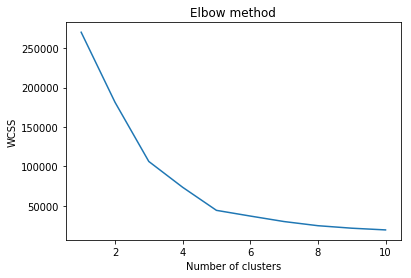

In [4]:
# using elbow method to find the optimal number of clusters
from sklearn.cluster import KMeans

wcss = []  # within cluster square of sums or inertia

# Here k-means++  ---> This assigns initial Centrod
# Here inertia_   ---> This gives Distortion value 

for i in range(1,11):
    #n_init:default=10 It is the no. of times the KMeans algorithm will be run with different initial centroid.
    kmeans_model = KMeans(n_clusters=i, 
                          init='k-means++',  
                          max_iter=300,
                          n_init=10, 
                          random_state=42)
    #train the model
    kmeans_model.fit(X)
    wcss.append(kmeans_model.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

>  so the appropriate value for k is 5 here. Elbow curve suddenly drops and becomes flat at K=5

### 3.2 Apply Kmean cluster with hardcoded cluster no K=5

In [5]:
kmean = KMeans(n_clusters=5, init='k-means++')
y_means = kmean.fit_predict(X)
y_means  # cluster IDs from 0 to 4    # This also same as kmean.labels_
#y_means : cluster numbers which input data belongs to

array([2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 1,
       2, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 0, 4, 1, 4, 0, 4, 0, 4,
       1, 4, 0, 4, 0, 4, 0, 4, 0, 4, 1, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4,
       0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4,
       0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4,
       0, 4])

In [6]:
#Centroid
centroid = kmean.cluster_centers_
print(" 5 Centroid of the cluster : \n" , centroid)

 5 Centroid of the cluster : 
 [[88.2        17.11428571]
 [55.2962963  49.51851852]
 [26.30434783 20.91304348]
 [25.72727273 79.36363636]
 [86.53846154 82.12820513]]


### 3.3 Check the lables of data point
 - Check the size of labels -- should match dataset count 

 - The cluster labels are returned in `kmeans.labels_`. 

In [7]:
print (kmean.labels_)
print (len(kmean.labels_))
print (len(dataset))

[2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2
 3 2 3 2 3 2 1 2 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 4 0 4 1 4 0 4 0 4 1 4 0 4 0 4 0 4 0 4 1 4 0 4 0 4
 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0
 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4]
200
200


## 4. Model Evaluation with Visualization

In [8]:
kmean.cluster_centers_  # centroid positions

array([[88.2       , 17.11428571],
       [55.2962963 , 49.51851852],
       [26.30434783, 20.91304348],
       [25.72727273, 79.36363636],
       [86.53846154, 82.12820513]])

### 4.1 How many people in each cluster?

In [9]:
print (type(kmean.labels_))
unique, counts = np.unique(kmean.labels_, return_counts=True)
print("\n Cluster No: " ,unique)
print("\n Each Cluster counts: " ,counts)
print("\n Each Cluster no : Cluster people counts: " ,dict(zip(unique, counts)))
new_dict = dict(zip(unique, counts))

<class 'numpy.ndarray'>

 Cluster No:  [0 1 2 3 4]

 Each Cluster counts:  [35 81 23 22 39]

 Each Cluster no : Cluster people counts:  {0: 35, 1: 81, 2: 23, 3: 22, 4: 39}


### 4.2 Tag labels or cluster no to original dataset

In [25]:
dataset['cluster'] = kmean.labels_
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,3
2,3,Female,20,16,6,2
3,4,Female,23,16,77,3
4,5,Female,31,17,40,2


### 4.3 Visualize the cluster based on cluster id to give color

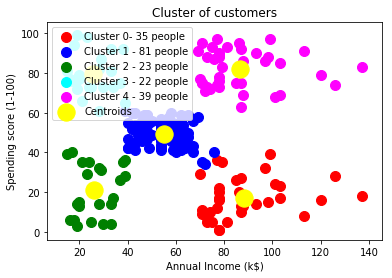

In [26]:
# visulizing the clusters
#Here X[y_means == 0, 0], X[y_means == 0, 1]   this part will gives X and Y axis values . both values are there in variable X
#X[y_means == 0, 0] if y_means == 0 means y_means is 1st cluster then take X[0] value as x axis point with cluster color 'red', label='Cluster 1'
#X[y_means == 0, 1] if y_means == 0 means y_means is 1st cluster then take X[1] value as y axis point with cluster color 'red', label='Cluster 1'
#X[0] --> Annual Income (k$) ,   X[1] --> Spending Score (1-100)

"""
Explaining visualization code
In general: plt.scatter(X_axis_data, Y_axis_data, ....)
In our code: X contains input data (X_axis_data, Y_axis_data) and y_means contains output 
    i.e cluster ids(0 to 4)
X[y_kmeans == 0, 0] -> first '0' means the cluster id 0, second 0 is first column of X,
    it would return X co-ordinates for cluster 0
X[y_kmeans == 0, 1] -> '0' means the cluster id 0, 1 is second column of X that is y-axis 
    for scatter method

s = 100 is the size

Cluster 1: careful
Cluster 2: Standard
Cluster 3: Target
Cluster 4: careless
Cluster 5: sensible
"""

plt.scatter(X[y_means == 0, 0], X[y_means == 0, 1],
           s=100, c='red', label='Cluster 0- %d people' %new_dict[0])
plt.scatter(X[y_means == 1, 0], X[y_means == 1, 1],
           s=100, c='blue', label='Cluster 1 - %d people' %new_dict[1])
plt.scatter(X[y_means == 2, 0], X[y_means == 2, 1],
           s=100, c='green', label='Cluster 2 - %d people' %new_dict[2])
plt.scatter(X[y_means == 3, 0], X[y_means == 3, 1],
           s=100, c='cyan', label='Cluster 3 - %d people' %new_dict[3])
plt.scatter(X[y_means == 4, 0], X[y_means == 4, 1],
           s=100, c='magenta', label='Cluster 4 - %d people' %new_dict[4])
plt.scatter(kmean.cluster_centers_[:,0], kmean.cluster_centers_[:,1],
            s=300, c='yellow', label='Centroids')
plt.title("Cluster of customers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending score (1-100)")
#plt.legend()
plt.legend(loc='upper left')
plt.show()

## 5. Conclusion

- cluster 0: careful
- cluster 1: standard
- cluster 2: No target
- cluster 3: careless
- cluster 4: sensible



You can see the data points in the form of five clusters. 
   -  Cluster 0 : The data points in the bottom right(Red) belong to the customers with high salaries but low spending. 
           - These are the customers that spend their money carefully. 
   -  Cluster 4 : Similarly, the customers at top right (Pink data points), these are the customers with high salaries and high spending.
            These are the type of customers that companies target. 
   - Cluster 1 : The customers in the middle (Blue data points) are the ones with average income and average salaries. 
           - The highest numbers of customers belong to this category. 
           - Companies can also target these customers given the fact that 
        they are in huge numbers, etc.
   -  Cluster 2 , 3 : Similarly, the customers at top left nand below left (Green and Light Blue data points), these are the customers with Low salaries and high and low spending. No need to target them

## 6. Rename cluster no in originl data 

In [27]:
# Append o/p to original dataset
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,3
2,3,Female,20,16,6,2
3,4,Female,23,16,77,3
4,5,Female,31,17,40,2


In [28]:
np.unique(dataset['cluster'])

array([0, 1, 2, 3, 4])

In [29]:
"""
- cluster 0: careful
- cluster 1: standard
- cluster 2: No target
- cluster 3: careless
- cluster 4: sensible

"""

dataset['cluster'] = dataset['cluster'].map({0:'careful',1:'standard',2:'No target',3:'careless', 4:'sensible'})
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,No target
1,2,Male,21,15,81,careless
2,3,Female,20,16,6,No target
3,4,Female,23,16,77,careless
4,5,Female,31,17,40,No target


### 6.1 By using this final Data we can target set of customer for target

- cluster 4: sensible  , High salary High spending

- cluster 0: careful  , High salary low spending

In [34]:
print(" Customer id which have High salary High spending: \n" , dataset[dataset["cluster"] == 'sensible'].CustomerID)

print("\n" +" ###"*10)

print("\n Customer id which have High salary Low spending: \n" , dataset[dataset["cluster"] == 'careful'].CustomerID)


 Customer id which have High salary High spending: 
 123    124
125    126
127    128
129    130
131    132
133    134
135    136
137    138
139    140
141    142
143    144
145    146
147    148
149    150
151    152
153    154
155    156
157    158
159    160
161    162
163    164
165    166
167    168
169    170
171    172
173    174
175    176
177    178
179    180
181    182
183    184
185    186
187    188
189    190
191    192
193    194
195    196
197    198
199    200
Name: CustomerID, dtype: int64

 ### ### ### ### ### ### ### ### ### ###

 Customer id which have High salary Low spending: 
 124    125
128    129
130    131
134    135
136    137
138    139
140    141
144    145
146    147
148    149
150    151
152    153
154    155
156    157
158    159
160    161
162    163
164    165
166    167
168    169
170    171
172    173
174    175
176    177
178    179
180    181
182    183
184    185
186    187
188    189
190    191
192    193
194    195
196    197
198    199
Name: C